<a href="https://colab.research.google.com/github/elliagustin/TheBiggerPicture/blob/main/Episode_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Codigo Comun**

In [ ]:
pip install ta

In [ ]:
# libraries
from sklearn.model_selection import train_test_split
from ta.trend import EMAIndicator, ADXIndicator
from ta.volatility import AverageTrueRange
from ta.momentum import RSIIndicator
import os, joblib
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# params
direction = 'long'
lookahead_hours = 1
target_points = 125
point_size = 0.00001
currency = 'EURUSD'

#  XGBClassifier params
n_estimators=500
max_depth=6
learning_rate=0.05
random_state=0

In [ ]:
# getting the data
df = pd.read_csv('/content/EURUSD.csv')
print(f"Successfully loaded {len(df)} rows from EURUSD.csv")
display(df.head())

Successfully loaded 33276 rows from EURUSD.csv


,Datetime,Open_EURUSD,High_EURUSD,Low_EURUSD,Close_EURUSD,Volume_EURUSD
0,2021-01-03 22:00:00,1.22400,1.22427,1.22324,1.22342,184
1,2021-01-03 23:00:00,1.22339,1.22528,1.22310,1.22500,1623
2,2021-01-04 00:00:00,1.22498,1.22498,1.22388,1.22409,2930
3,2021-01-04 01:00:00,1.22410,1.22558,1.22400,1.22527,3149
4,2021-01-04 02:00:00,1.22526,1.22586,1.22496,1.22542,2640


In [ ]:
# defintion
target_move = target_points * point_size

# Column datetime to datime type and convert to index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')

# Fill NaN values in 'Volume_EURUSD' with 0 before converting to int
df['Volume_EURUSD'] = df['Volume_EURUSD'].fillna(0)

# Convert 'Volume_EURUSD' column to integer type
df['Volume_EURUSD'] = df['Volume_EURUSD'].astype(int)

print("Data type of 'Volume_EURUSD' column after conversion:")
df.info()

Data type of 'Volume_EURUSD' column after conversion:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 33276 entries, 2021-01-03 22:00:00 to 2026-05-07 18:00:00
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open_EURUSD    33276 non-null  float64
 1   High_EURUSD    33276 non-null  float64
 2   Low_EURUSD     33276 non-null  float64
 3   Close_EURUSD   33276 non-null  float64
 4   Volume_EURUSD  33276 non-null  int64  
dtypes: float64(4), int64(1)
memory usage: 1.5 MB


In [ ]:
# 2 - Preparacion: CatBoost no necesita normalizacion
X = df.copy()
X = X[['Close_EURUSD','Open_EURUSD','High_EURUSD','Low_EURUSD','Volume_EURUSD']]
X[['Close_EURUSD','Open_EURUSD','High_EURUSD','Low_EURUSD']] = X[['Close_EURUSD','Open_EURUSD','High_EURUSD','Low_EURUSD']]
X['Hour'] = X.index.hour
X['Day_of_Week'] = X.index.dayofweek    # Monday=0
X['Volume_EURUSD'] = X['Volume_EURUSD']
X['EMA_9'] = EMAIndicator(close=X['Close_EURUSD'], window=9).ema_indicator()
X['EMA_20'] = EMAIndicator(close=X['Close_EURUSD'], window=20).ema_indicator()
X['EMA_50'] = EMAIndicator(close=X['Close_EURUSD'], window=50).ema_indicator()
X['EMA_100'] = EMAIndicator(close=X['Close_EURUSD'], window=100).ema_indicator()
X['EMA_200'] = EMAIndicator(close=X['Close_EURUSD'], window=200).ema_indicator()

# New indicator test: RSI
X['RSI_14'] = RSIIndicator(close=X['Close_EURUSD'], window=14).rsi()
X['ATR_14'] = AverageTrueRange(high=X['High_EURUSD'],low=X['Low_EURUSD'],close=X['Close_EURUSD'],window=14).average_true_range()
X['ADX_9'] = ADXIndicator(high=X['High_EURUSD'],low=X['Low_EURUSD'],close=X['Close_EURUSD'],window=9).adx()

# Remove rows with null values
X_ready = X.iloc[200-1:].copy()

In [ ]:
if direction == "long":
    future_max = (
        X_ready['High_EURUSD']
        .shift(-1)
        .rolling(window=lookahead_hours)
        .max()
        .shift(-(lookahead_hours - 1))
    )
    X_ready['y'] = (future_max >= X_ready['Close_EURUSD'] + target_move).astype(int)

elif direction == "short":
    future_min = (
        X_ready['Low_EURUSD']
        .shift(-1)
        .rolling(window=lookahead_hours)
        .min()
        .shift(-(lookahead_hours - 1))
    )
    X_ready['y'] = (future_min <= X_ready['Close_EURUSD'] - target_move).astype(int)

X_ready = X_ready.iloc[:-lookahead_hours].copy()

# Distribution check
X_ready['y'].value_counts(normalize=True)

,proportion
y,
0,0.54339
1,0.45661


In [ ]:
# model definition
# model = XGBClassifier(
#     n_estimators=n_estimators,
#     max_depth=max_depth,
#     learning_rate=learning_rate,
#     random_state=random_state
# )

# model = XGBClassifier(
#     n_estimators=300,
#     max_depth=3,
#     learning_rate=0.03,
#     min_child_weight=10,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     reg_alpha=0.5,
#     reg_lambda=5,
#     random_state=0,
#     eval_metric="logloss"
# )

model = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.2,
    reg_lambda=3,
    random_state=0,
    eval_metric="logloss"
)

# **1 - RSI**

In [ ]:
# 4 - Defining the feature sets to evaluate
print('2.Define models and fine-tuned variations')
from xgboost import XGBClassifier
np.random.seed(0)

base_features = [
    'Close_EURUSD',
    'Open_EURUSD',
    'High_EURUSD',
    'Low_EURUSD',
    'Volume_EURUSD',
    'Hour',
    'Day_of_Week',
    'EMA_9',
    'EMA_20',
    'EMA_50',
    'EMA_100',
    'EMA_200'
]

feature_sets = {
    "New Baseline": base_features,
    "New Baseline + RSI_14": base_features + ['RSI_14']
}

results = []
thresholds = [0.55, 0.575, 0.6, 0.625, 0.65, 0.675, 0.7, 0.725, 0.75, 0.775, 0.8]

2.Define models and fine-tuned variations


In [ ]:
for model_name, feature_cols in feature_sets.items():
    print(f'Training {model_name}')

    X_ready = X_ready.sort_index()
    df = X_ready[feature_cols]
    y = X_ready['y']

    # Split (time-based)
    x_aux, x_test, y_aux, y_test = train_test_split(df, y, test_size=0.2, shuffle=False)
    x_train, x_val, y_train, y_val = train_test_split(x_aux, y_aux, test_size=0.2, shuffle=False)

    # Train
    model.fit(x_train, y_train)

    # Probabilities
    y_prob_train = model.predict_proba(x_train)[:, 1]
    y_prob_val = model.predict_proba(x_val)[:, 1]
    y_prob_test = model.predict_proba(x_test)[:, 1]

    for threshold in thresholds:
        # Thresholded predictions
        y_pred_train = (y_prob_train > threshold).astype(int)
        y_pred_val = (y_prob_val > threshold).astype(int)
        y_pred_test = (y_prob_test > threshold).astype(int)

        n_trades_val = y_pred_val.sum()
        n_trades_test = y_pred_test.sum()


        # Metrics
        row = {
            "model": model_name,
            "threshold": threshold,

            # trades
            "n_trades_val": n_trades_val,
            "n_trades_test": n_trades_test,

            # Class 1 focus (important)
            "val_precision_1": precision_score(y_val, y_pred_val, pos_label=1, zero_division=0),
            "val_recall_1": recall_score(y_val, y_pred_val, pos_label=1),
            "val_f1_1": f1_score(y_val, y_pred_val, pos_label=1),

            "test_precision_1": precision_score(y_test, y_pred_test, pos_label=1, zero_division=0),
            "test_recall_1": recall_score(y_test, y_pred_test, pos_label=1),
            "test_f1_1": f1_score(y_test, y_pred_test, pos_label=1),
        }

        results.append(row)

    # Save model
    os.makedirs(f"models/{direction}", exist_ok=True)
    filename = f"models/{direction}/{model_name}_{currency}.pkl"
    joblib.dump(model, filename)


results_df = pd.DataFrame(results).sort_values(by="test_f1_1", ascending=False)

# Calculate the number of weeks in the test set from x_test
# x_test is available from the last model training run and represents the test period
num_weeks_in_val_set = len(x_val.resample('W'))
num_weeks_in_test_set = len(x_test.resample('W'))

# Add a new column to results_df: average number of trades per week
results_df['avg_weekly_trades_val'] = results_df['n_trades_val'] / num_weeks_in_val_set
results_df['avg_weekly_trades_test'] = results_df['n_trades_test'] / num_weeks_in_test_set

# Distribution check
print('-')
print('Results')
display(results_df.head())

Training New Baseline
Training New Baseline + RSI_14
-
Results


,model,threshold,n_trades_val,n_trades_test,val_precision_1,val_recall_1,val_f1_1,test_precision_1,test_recall_1,test_f1_1,avg_weekly_trades_val,avg_weekly_trades_test
11,New Baseline + RSI_14,0.550,2478,1692,0.575464,0.625164,0.599286,0.608747,0.321273,0.420580,53.869565,30.214286
0,New Baseline,0.550,2425,1582,0.580206,0.616835,0.597960,0.616308,0.304117,0.407268,52.717391,28.250000
12,New Baseline + RSI_14,0.575,2175,1242,0.596322,0.568610,0.582136,0.619163,0.239863,0.345773,47.282609,22.178571
1,New Baseline,0.575,2123,1150,0.602920,0.561157,0.581290,0.624348,0.223955,0.329660,46.152174,20.535714
13,New Baseline + RSI_14,0.600,1832,851,0.614629,0.493643,0.547532,0.646298,0.171553,0.271136,39.826087,15.196429


# **1 - RSI Chart**

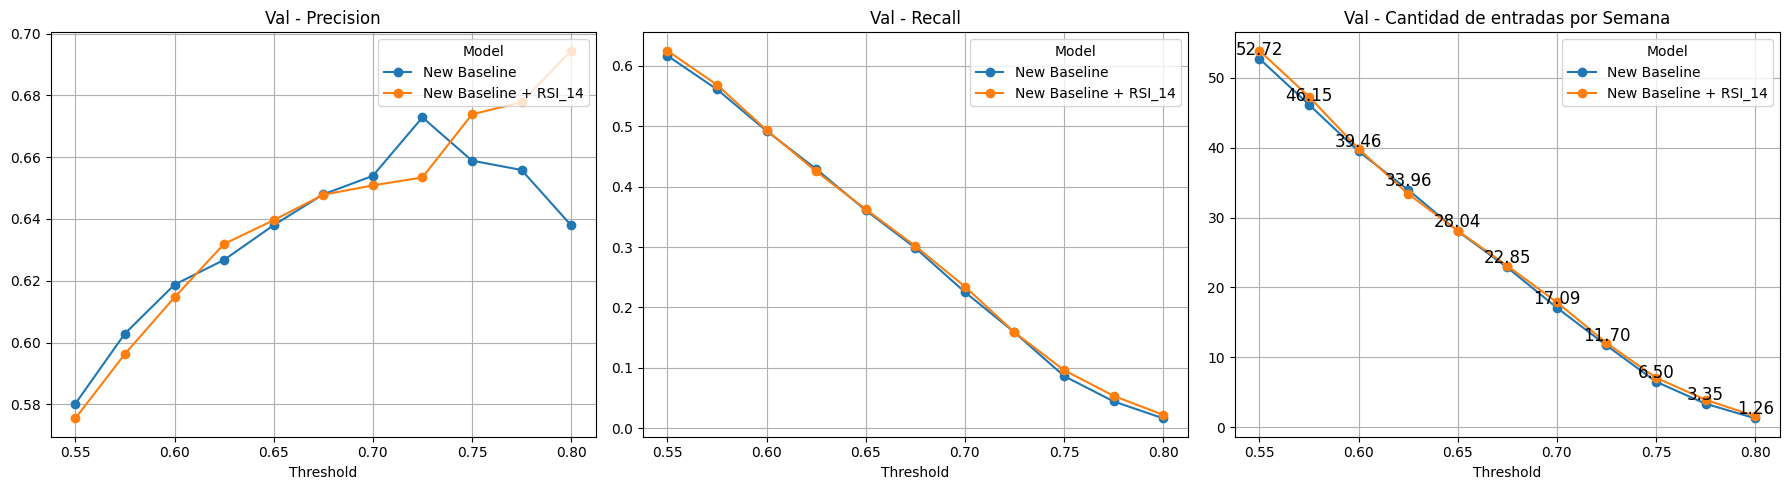

In [ ]:
metrics = [
    ("val_precision_1", "Val - Precision"),
    ("val_recall_1", "Val - Recall"),
    ("avg_weekly_trades_val", "Val - Cantidad de entradas por Semana") ]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (metric, title) in enumerate(metrics):
    ax = axes[i] # Get the current subplot axis

    pivot = results_df.pivot(
        index="threshold",
        columns="model",
        values=metric
    )

    pivot.plot(marker="o", ax=ax)
    ax.set_title(title)
    ax.grid()
    ax.set_xlabel("Threshold")
    ax.legend(title='Model', loc='upper right') # Ensure legend is top right for all charts

    # Add data point values only to the 'New Baseline' series of the LAST chart
    if i == len(metrics) - 1: # Check if it's the last metric (0-indexed)
        # Iterate over the 'New Baseline' series for the current metric
        for threshold, value in zip(pivot.index, pivot['New Baseline']):
            ax.text(threshold, value, f'{value:.2f}',
                    ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

# **2 - ATR**

In [ ]:
# 4 - Defining the feature sets to evaluate
print('2.Define models and fine-tuned variations')
from xgboost import XGBClassifier
np.random.seed(0)

base_features = [
    'Close_EURUSD',
    'Open_EURUSD',
    'High_EURUSD',
    'Low_EURUSD',
    'Volume_EURUSD',
    'Hour',
    'Day_of_Week',
    'EMA_9',
    'EMA_20',
    'EMA_50',
    'EMA_100',
    'EMA_200'
]

feature_sets = {
    "New Baseline": base_features,
    "New Baseline + ATR_14": base_features + ['ATR_14']
}

results = []
thresholds = [0.55, 0.575, 0.6, 0.625, 0.65, 0.675, 0.7, 0.725, 0.75, 0.775, 0.8]

2.Define models and fine-tuned variations


In [ ]:
for model_name, feature_cols in feature_sets.items():
    print(f'Training {model_name}')

    X_ready = X_ready.sort_index()
    df = X_ready[feature_cols]
    y = X_ready['y']

    # Split (time-based)
    x_aux, x_test, y_aux, y_test = train_test_split(df, y, test_size=0.2, shuffle=False)
    x_train, x_val, y_train, y_val = train_test_split(x_aux, y_aux, test_size=0.2, shuffle=False)

    # Train
    model.fit(x_train, y_train)

    # Probabilities
    y_prob_train = model.predict_proba(x_train)[:, 1]
    y_prob_val = model.predict_proba(x_val)[:, 1]
    y_prob_test = model.predict_proba(x_test)[:, 1]

    for threshold in thresholds:
        # Thresholded predictions
        y_pred_train = (y_prob_train > threshold).astype(int)
        y_pred_val = (y_prob_val > threshold).astype(int)
        y_pred_test = (y_prob_test > threshold).astype(int)

        n_trades_val = y_pred_val.sum()
        n_trades_test = y_pred_test.sum()


        # Metrics
        row = {
            "model": model_name,
            "threshold": threshold,

            # trades
            "n_trades_val": n_trades_val,
            "n_trades_test": n_trades_test,

            # Class 1 focus (important)
            "val_precision_1": precision_score(y_val, y_pred_val, pos_label=1, zero_division=0),
            "val_recall_1": recall_score(y_val, y_pred_val, pos_label=1),
            "val_f1_1": f1_score(y_val, y_pred_val, pos_label=1),

            "test_precision_1": precision_score(y_test, y_pred_test, pos_label=1, zero_division=0),
            "test_recall_1": recall_score(y_test, y_pred_test, pos_label=1),
            "test_f1_1": f1_score(y_test, y_pred_test, pos_label=1),
        }

        results.append(row)

    # Save model
    os.makedirs(f"models/{direction}", exist_ok=True)
    filename = f"models/{direction}/{model_name}_{currency}.pkl"
    joblib.dump(model, filename)


results_df = pd.DataFrame(results).sort_values(by="test_f1_1", ascending=False)

# Calculate the number of weeks in the test set from x_test
# x_test is available from the last model training run and represents the test period
num_weeks_in_val_set = len(x_val.resample('W'))
num_weeks_in_test_set = len(x_test.resample('W'))

# Add a new column to results_df: average number of trades per week
results_df['avg_weekly_trades_val'] = results_df['n_trades_val'] / num_weeks_in_val_set
results_df['avg_weekly_trades_test'] = results_df['n_trades_test'] / num_weeks_in_test_set

display(results_df.head())


Training New Baseline
Training New Baseline + ATR_14


,model,threshold,n_trades_val,n_trades_test,val_precision_1,val_recall_1,val_f1_1,test_precision_1,test_recall_1,test_f1_1,avg_weekly_trades_val,avg_weekly_trades_test
11,New Baseline + ATR_14,0.550,2127,2218,0.621063,0.579132,0.599365,0.619026,0.428260,0.506268,46.239130,39.607143
12,New Baseline + ATR_14,0.575,1877,1803,0.636121,0.523455,0.574315,0.623405,0.350593,0.448792,40.804348,32.196429
0,New Baseline,0.550,2425,1582,0.580206,0.616835,0.597960,0.616308,0.304117,0.407268,52.717391,28.250000
13,New Baseline + ATR_14,0.600,1646,1360,0.649453,0.468654,0.544436,0.641912,0.272302,0.382392,35.782609,24.285714
1,New Baseline,0.575,2123,1150,0.602920,0.561157,0.581290,0.624348,0.223955,0.329660,46.152174,20.535714


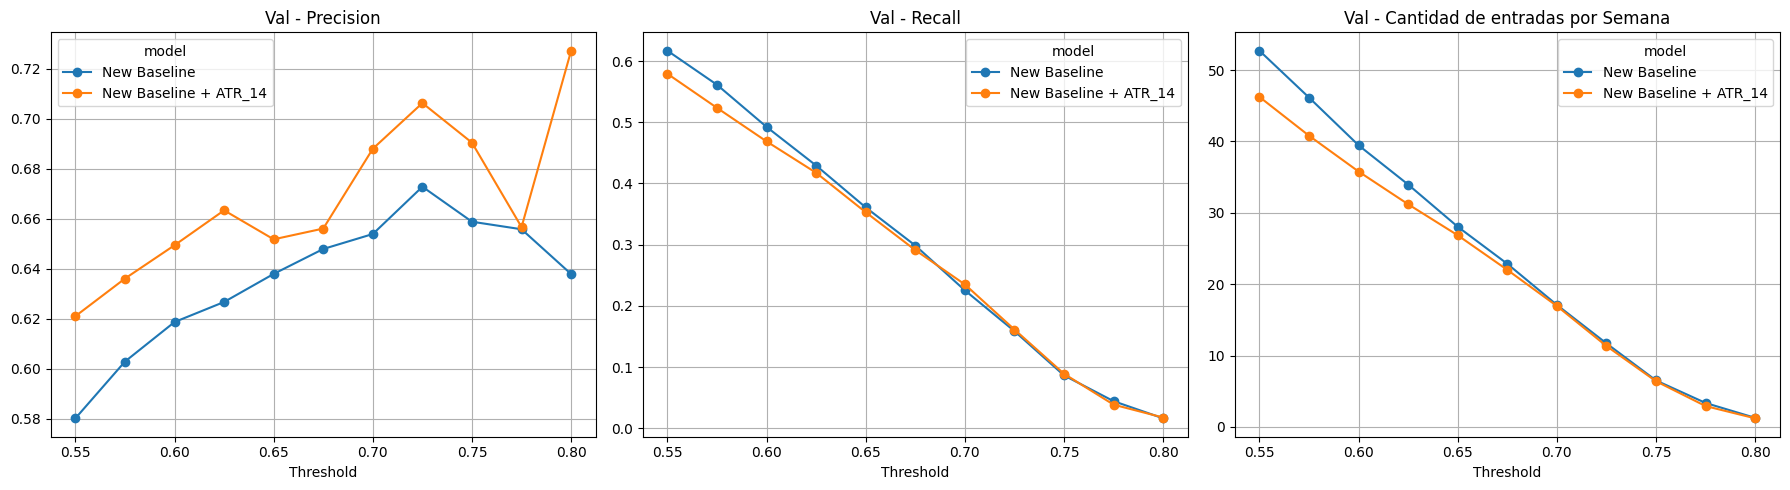

In [ ]:
metrics = [
    ("val_precision_1", "Val - Precision"),
    ("val_recall_1", "Val - Recall"),
    ("avg_weekly_trades_val", "Val - Cantidad de entradas por Semana") ]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric, title) in zip(axes, metrics):
    pivot = results_df.pivot(
        index="threshold",
        columns="model",
        values=metric
    )

    pivot.plot(marker="o", ax=ax)
    ax.set_title(title)
    ax.grid()
    ax.set_xlabel("Threshold")

plt.tight_layout()
plt.show()

# **3 - ADX**

In [ ]:
# 4 - Defining the feature sets to evaluate
print('2.Define models and fine-tuned variations')
from xgboost import XGBClassifier
np.random.seed(0)

base_features = [
    'Close_EURUSD',
    'Open_EURUSD',
    'High_EURUSD',
    'Low_EURUSD',
    'Volume_EURUSD',
    'Hour',
    'Day_of_Week',
    'EMA_9',
    'EMA_20',
    'EMA_50',
    'EMA_100',
    'EMA_200'
]

feature_sets = {
    "New Baseline": base_features,
    "New Baseline + ADX_9": base_features + ['ADX_9']
}

results = []
thresholds = [0.55, 0.575, 0.6, 0.625, 0.65, 0.675, 0.7, 0.725, 0.75, 0.775, 0.8]

2.Define models and fine-tuned variations


In [ ]:
for model_name, feature_cols in feature_sets.items():
    print(f'Training {model_name}')

    X_ready = X_ready.sort_index()
    df = X_ready[feature_cols]
    y = X_ready['y']

    # Split (time-based)
    x_aux, x_test, y_aux, y_test = train_test_split(df, y, test_size=0.2, shuffle=False)
    x_train, x_val, y_train, y_val = train_test_split(x_aux, y_aux, test_size=0.2, shuffle=False)

    # Train
    model.fit(x_train, y_train)

    # Probabilities
    y_prob_train = model.predict_proba(x_train)[:, 1]
    y_prob_val = model.predict_proba(x_val)[:, 1]
    y_prob_test = model.predict_proba(x_test)[:, 1]

    for threshold in thresholds:
        # Thresholded predictions
        y_pred_train = (y_prob_train > threshold).astype(int)
        y_pred_val = (y_prob_val > threshold).astype(int)
        y_pred_test = (y_prob_test > threshold).astype(int)

        n_trades_val = y_pred_val.sum()
        n_trades_test = y_pred_test.sum()


        # Metrics
        row = {
            "model": model_name,
            "threshold": threshold,

            # trades
            "n_trades_val": n_trades_val,
            "n_trades_test": n_trades_test,

            # Class 1 focus (important)
            "val_precision_1": precision_score(y_val, y_pred_val, pos_label=1, zero_division=0),
            "val_recall_1": recall_score(y_val, y_pred_val, pos_label=1),
            "val_f1_1": f1_score(y_val, y_pred_val, pos_label=1),

            "test_precision_1": precision_score(y_test, y_pred_test, pos_label=1, zero_division=0),
            "test_recall_1": recall_score(y_test, y_pred_test, pos_label=1),
            "test_f1_1": f1_score(y_test, y_pred_test, pos_label=1),
        }

        results.append(row)

    # Save model
    os.makedirs(f"models/{direction}", exist_ok=True)
    filename = f"models/{direction}/{model_name}_{currency}.pkl"
    joblib.dump(model, filename)


results_df = pd.DataFrame(results).sort_values(by="test_f1_1", ascending=False)

# Calculate the number of weeks in the test set from x_test
# x_test is available from the last model training run and represents the test period
num_weeks_in_val_set = len(x_val.resample('W'))
num_weeks_in_test_set = len(x_test.resample('W'))

# Add a new column to results_df: average number of trades per week
results_df['avg_weekly_trades_val'] = results_df['n_trades_val'] / num_weeks_in_val_set
results_df['avg_weekly_trades_test'] = results_df['n_trades_test'] / num_weeks_in_test_set

display(results_df.head())


Training New Baseline
Training New Baseline + ADX_9


,model,threshold,n_trades_val,n_trades_test,val_precision_1,val_recall_1,val_f1_1,test_precision_1,test_recall_1,test_f1_1,avg_weekly_trades_val,avg_weekly_trades_test
11,New Baseline + ADX_9,0.550,2473,1670,0.580267,0.629110,0.603702,0.607784,0.316594,0.416325,53.760870,29.821429
0,New Baseline,0.550,2425,1582,0.580206,0.616835,0.597960,0.616308,0.304117,0.407268,52.717391,28.250000
1,New Baseline,0.575,2123,1150,0.602920,0.561157,0.581290,0.624348,0.223955,0.329660,46.152174,20.535714
12,New Baseline + ADX_9,0.575,2132,1157,0.606942,0.567295,0.586449,0.621435,0.224267,0.329590,46.347826,20.660714
13,New Baseline + ADX_9,0.600,1845,775,0.622764,0.503726,0.556956,0.654194,0.158141,0.254710,40.108696,13.839286


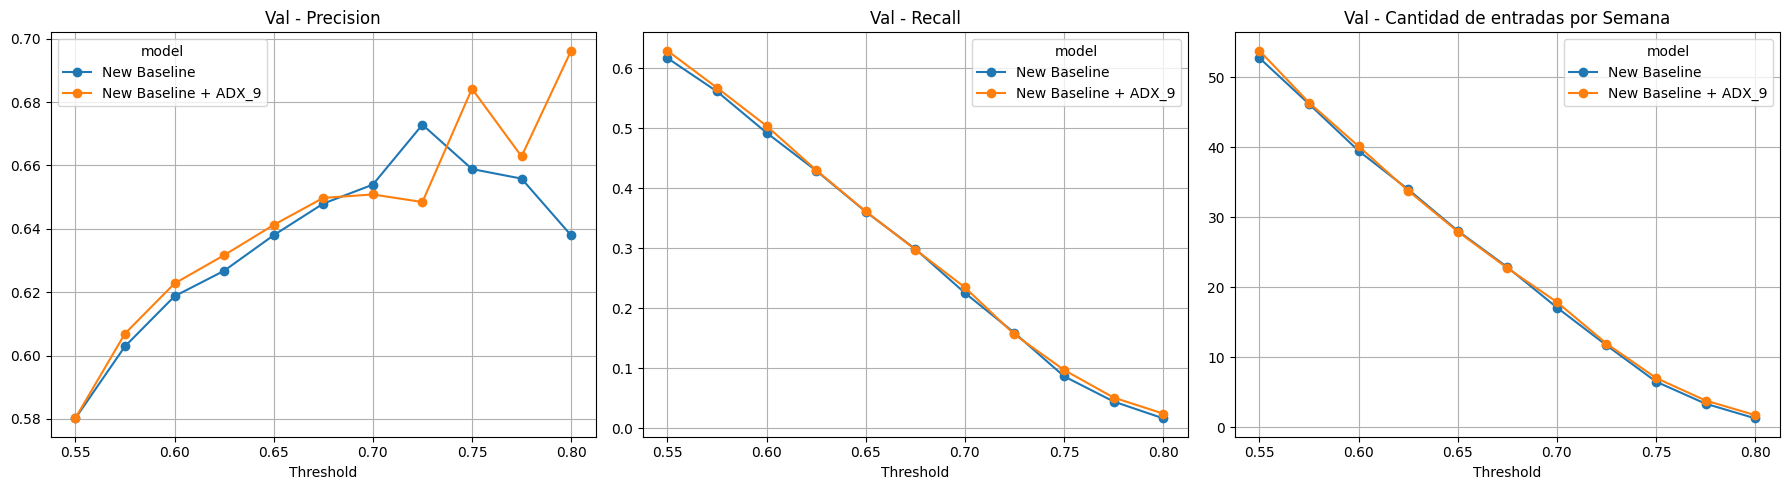

In [ ]:
metrics = [
    ("val_precision_1", "Val - Precision"),
    ("val_recall_1", "Val - Recall"),
    ("avg_weekly_trades_val", "Val - Cantidad de entradas por Semana") ]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (metric, title) in zip(axes, metrics):
    pivot = results_df.pivot(
        index="threshold",
        columns="model",
        values=metric
    )

    pivot.plot(marker="o", ax=ax)
    ax.set_title(title)
    ax.grid()
    ax.set_xlabel("Threshold")

plt.tight_layout()
plt.show()